In [2]:
import pandas as pd

# Load CSV files
company_tweet = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/raw/tweet_data_new/Company_Tweet.csv')
price_data = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/raw/tweet_data_new/CompanyValues.csv')

In [3]:
pagerank_weighted_sentiment_label = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Master_Thesis//src/models/tweet_influencer/pagerank_weighted_sentiment.csv')

In [4]:
pagerank_weighted_sentiment_label.head()

,tweet_id,created_at,sentiment,weighted_sentiment
0,797587806331830273,2016-11-12 23:52:06,negative,-0.000163
1,797589836278464512,2016-11-13 00:00:10,negative,-0.000163
2,797590101140340736,2016-11-13 00:01:13,positive,0.000167
3,797591064081301536,2016-11-13 00:05:02,positive,0.000163
4,797591529908883456,2016-11-13 00:06:53,positive,0.000164


In [5]:

# Step 1: Merge tweets with ticker symbol
pagerank_weighted_sentiment_label_merged = pd.merge(pagerank_weighted_sentiment_label, company_tweet, on='tweet_id', how='inner')

In [6]:
pagerank_weighted_sentiment_label_merged.head()

,tweet_id,created_at,sentiment,weighted_sentiment,ticker_symbol
0,797587806331830273,2016-11-12 23:52:06,negative,-0.000163,AMZN
1,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,AAPL
2,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,TSLA
3,797590101140340736,2016-11-13 00:01:13,positive,0.000167,AAPL
4,797591064081301536,2016-11-13 00:05:02,positive,0.000163,AAPL


In [7]:
# Group by ticker and count tweets
tweet_distribution = pagerank_weighted_sentiment_label_merged.groupby('ticker_symbol')['tweet_id'].nunique().sort_values(ascending=False)

# Display result
print(tweet_distribution)


ticker_symbol
AAPL     1387308
TSLA     1067549
AMZN      705285
GOOG      383184
MSFT      371144
GOOGL     321206
Name: tweet_id, dtype: int64


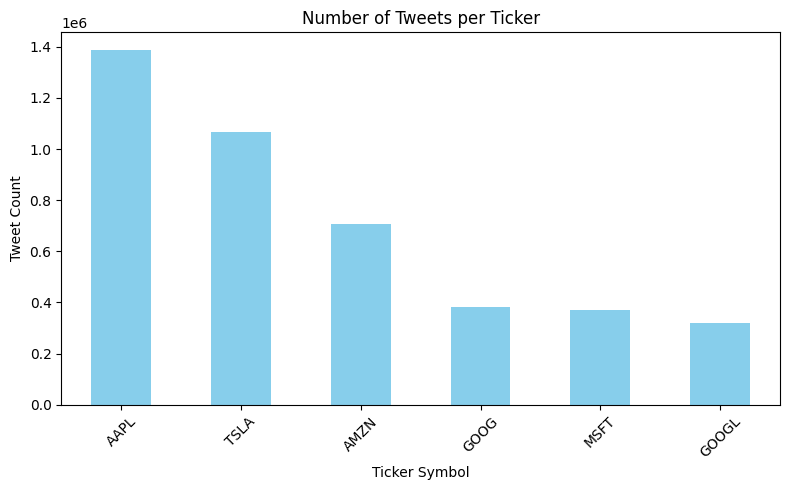

In [8]:
import matplotlib.pyplot as plt

# Plot
tweet_distribution.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Number of Tweets per Ticker')
plt.xlabel('Ticker Symbol')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
# Group by ticker and sentiment
sentiment_dist = pagerank_weighted_sentiment_label_merged.groupby(['ticker_symbol', 'sentiment'])['tweet_id'].nunique().unstack().fillna(0)

# Display the table
print(sentiment_dist)


sentiment      negative  neutral  positive
ticker_symbol                             
AAPL             331498   530484    525326
AMZN             150286   230900    324099
GOOG              79198   157127    146859
GOOGL             71277   119136    130793
MSFT              71128   151804    148212
TSLA             329757   289582    448210


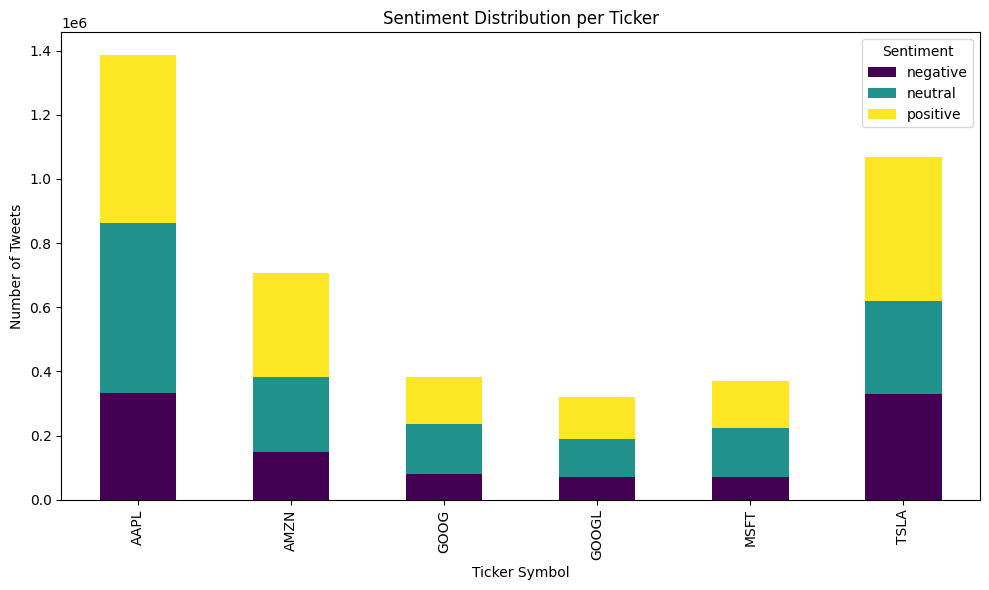

In [10]:
import matplotlib.pyplot as plt

# Interactive mode
plt.ion()

# Data (recreate if not already available)
sentiment_dist = pagerank_weighted_sentiment_label_merged.groupby(['ticker_symbol', 'sentiment'])['tweet_id'].nunique().unstack().fillna(0)

# Plot
sentiment_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Sentiment Distribution per Ticker')
plt.xlabel('Ticker Symbol')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show(block=True)  # Ensures window stays open in VS Code


In [ ]:
# Define mapping dictionary
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}

# Apply the mapping
pagerank_weighted_sentiment_label_merged['sentiment_mapped'] = pagerank_weighted_sentiment_label_merged['sentiment'].map(sentiment_map)



In [15]:
pagerank_weighted_sentiment_label_merged.head()

,tweet_id,created_at,sentiment,weighted_sentiment,ticker_symbol,sentiment_mapped
0,797587806331830273,2016-11-12 23:52:06,negative,-0.000163,AMZN,-1
1,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,AAPL,-1
2,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,TSLA,-1
3,797590101140340736,2016-11-13 00:01:13,positive,0.000167,AAPL,1
4,797591064081301536,2016-11-13 00:05:02,positive,0.000163,AAPL,1


In [16]:
pagerank_weighted_sentiment_label_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4235676 entries, 0 to 4235675
Data columns (total 6 columns):
 #   Column              Dtype  
---  ------              -----  
 0   tweet_id            int64  
 1   created_at          object 
 2   sentiment           object 
 3   weighted_sentiment  float64
 4   ticker_symbol       object 
 5   sentiment_mapped    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 193.9+ MB


In [17]:
# Step 2: Convert 'created_at' to date
pagerank_weighted_sentiment_label_merged['date'] = pd.to_datetime(pagerank_weighted_sentiment_label_merged['created_at']).dt.date

In [18]:
pagerank_weighted_sentiment_label_merged['date'].nunique()

1826

In [19]:
pagerank_weighted_sentiment_label_merged.head()

,tweet_id,created_at,sentiment,weighted_sentiment,ticker_symbol,sentiment_mapped,date
0,797587806331830273,2016-11-12 23:52:06,negative,-0.000163,AMZN,-1,2016-11-12
1,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,AAPL,-1,2016-11-13
2,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,TSLA,-1,2016-11-13
3,797590101140340736,2016-11-13 00:01:13,positive,0.000167,AAPL,1,2016-11-13
4,797591064081301536,2016-11-13 00:05:02,positive,0.000163,AAPL,1,2016-11-13


In [20]:
# Ensure created_at is datetime
pagerank_weighted_sentiment_label_merged['created_at'] = pd.to_datetime(pagerank_weighted_sentiment_label_merged['created_at'])

# Filter for TSLA on 2019-12-19 between 09:30 and 16:00
start_time = pd.to_datetime('2019-12-19 09:30:00')
end_time = pd.to_datetime('2019-12-19 16:00:00')

mask = (
    (pagerank_weighted_sentiment_label_merged['ticker_symbol'] == 'TSLA') &
    (pagerank_weighted_sentiment_label_merged['created_at'] >= start_time) &
    (pagerank_weighted_sentiment_label_merged['created_at'] <= end_time)
)

# Show tweets in that window
pagerank_weighted_sentiment_label_merged.loc[mask]


,tweet_id,created_at,sentiment,weighted_sentiment,ticker_symbol,sentiment_mapped,date



This code assigns each tweet to a market **period** and determines the **sentiment date**—the trading day the tweet is expected to influence—based on the time it was posted:

###  Logic:

* **`open_to_close`**:
  If the tweet was posted **during market hours** (9:30 AM to 4:00 PM on a trading day), its sentiment is assumed to affect **the same day’s market**.

* **`close_to_open`**:
  If the tweet was posted **after market close**, **before market open**, or on a **non-trading day** (weekends or holidays), its sentiment is assumed to influence **the next trading day’s opening**.

###  Implementation:

* Uses the official NYSE calendar (`pandas_market_calendars`) to identify valid trading days.
* Computes two columns:

  * `period`: `'open_to_close'` or `'close_to_open'`
  * `sentiment_date`: the trading day on which the sentiment should be applied

This ensures that sentiment signals align correctly with real-world market behavior.


In [21]:
import pandas as pd
import numpy as np
from datetime import datetime, time
import pandas_market_calendars as mcal

# Get NYSE calendar and convert to timezone-naive Timestamps
nyse = mcal.get_calendar('NYSE')
trading_days = nyse.valid_days(start_date='2015-01-01', end_date='2020-12-31').tz_localize(None)
trading_days_set = set(trading_days)

# Define market open and close times
market_open = time(9, 30)
market_close = time(16, 0)

# Sample DataFrame
df = pagerank_weighted_sentiment_label_merged.copy()
df['created_at'] = pd.to_datetime(df['created_at'])
df['date'] = df['created_at'].dt.date
df['time'] = df['created_at'].dt.time

# Helper: get next trading day
def get_next_trading_day(current_date):
    current_date_ts = pd.Timestamp(current_date)
    future_days = sorted([d for d in trading_days if d > current_date_ts])
    return future_days[0] if future_days else current_date_ts

# Helper: get previous trading day
def get_prev_trading_day(current_date):
    current_date_ts = pd.Timestamp(current_date)
    past_days = sorted([d for d in trading_days if d < current_date_ts])
    return past_days[-1] if past_days else current_date_ts

# Assign period and sentiment date
def determine_period_and_date(row):
    current_date = pd.Timestamp(row['date'])
    current_time = row['time']

    if current_date not in trading_days_set:
        period = 'close_to_open'
        sentiment_date = get_next_trading_day(current_date)
    elif current_time >= market_close or current_time < market_open:
        period = 'close_to_open'
        if current_time >= market_close:
            sentiment_date = get_next_trading_day(current_date)
        else:
            sentiment_date = current_date
    else:
        period = 'open_to_close'
        sentiment_date = current_date

    return pd.Series([period, sentiment_date])

# Apply
df[['period', 'sentiment_date']] = df.apply(determine_period_and_date, axis=1)




In [30]:
# Optional: view result
print(df[['created_at', 'time', 'period', 'sentiment_date']].head(20))

            created_at      time         period sentiment_date
0  2016-11-12 23:52:06  23:52:06  close_to_open     2016-11-14
1  2016-11-13 00:00:10  00:00:10  close_to_open     2016-11-14
2  2016-11-13 00:00:10  00:00:10  close_to_open     2016-11-14
3  2016-11-13 00:01:13  00:01:13  close_to_open     2016-11-14
4  2016-11-13 00:05:02  00:05:02  close_to_open     2016-11-14
5  2016-11-13 00:06:53  00:06:53  close_to_open     2016-11-14
6  2016-11-13 00:07:55  00:07:55  close_to_open     2016-11-14
7  2016-11-13 00:08:06  00:08:06  close_to_open     2016-11-14
8  2016-11-13 00:12:51  00:12:51  close_to_open     2016-11-14
9  2016-11-13 00:18:32  00:18:32  close_to_open     2016-11-14
10 2016-11-13 00:19:00  00:19:00  close_to_open     2016-11-14
11 2016-11-13 00:21:01  00:21:01  close_to_open     2016-11-14
12 2016-11-13 00:21:24  00:21:24  close_to_open     2016-11-14
13 2016-11-13 00:21:24  00:21:24  close_to_open     2016-11-14
14 2016-11-13 00:21:24  00:21:24  close_to_open     201

In [31]:
df.head(20)

,tweet_id,created_at,sentiment,weighted_sentiment,ticker_symbol,sentiment_mapped,date,time,period,sentiment_date
0,797587806331830273,2016-11-12 23:52:06,negative,-0.000163,AMZN,-1,2016-11-12,23:52:06,close_to_open,2016-11-14
1,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,AAPL,-1,2016-11-13,00:00:10,close_to_open,2016-11-14
2,797589836278464512,2016-11-13 00:00:10,negative,-0.000163,TSLA,-1,2016-11-13,00:00:10,close_to_open,2016-11-14
3,797590101140340736,2016-11-13 00:01:13,positive,0.000167,AAPL,1,2016-11-13,00:01:13,close_to_open,2016-11-14
4,797591064081301536,2016-11-13 00:05:02,positive,0.000163,AAPL,1,2016-11-13,00:05:02,close_to_open,2016-11-14
5,797591529908883456,2016-11-13 00:06:53,positive,0.000164,AAPL,1,2016-11-13,00:06:53,close_to_open,2016-11-14
6,797591786499796993,2016-11-13 00:07:55,neutral,0.000000,AAPL,0,2016-11-13,00:07:55,close_to_open,2016-11-14
7,797591835799617536,2016-11-13 00:08:06,positive,0.000163,AAPL,1,2016-11-13,00:08:06,close_to_open,2016-11-14
8,797593027615158272,2016-11-13 00:12:51,neutral,0.000000,AAPL,0,2016-11-13,00:12:51,close_to_open,2016-11-14
9,797594458623619072,2016-11-13 00:18:32,neutral,0.000000,AMZN,0,2016-11-13,00:18:32,close_to_open,2016-11-14


In [32]:
pagerank_weighted_sentiment_label_merged=df.copy()
aggregation_pagerank = pagerank_weighted_sentiment_label_merged.groupby(['ticker_symbol', 'sentiment_date', 'period']).agg({
    'sentiment_mapped' : 'mean',
    'weighted_sentiment' : 'mean'
}).reset_index()

In [33]:
print(aggregation_pagerank)

      ticker_symbol sentiment_date         period  sentiment_mapped  \
0              AAPL     2015-01-02  close_to_open          0.094872   
1              AAPL     2015-01-02  open_to_close         -0.111111   
2              AAPL     2015-01-05  close_to_open          0.100224   
3              AAPL     2015-01-05  open_to_close          0.009231   
4              AAPL     2015-01-06  close_to_open         -0.005807   
...             ...            ...            ...               ...   
14948          TSLA     2019-12-30  close_to_open          0.163389   
14949          TSLA     2019-12-30  open_to_close          0.149289   
14950          TSLA     2019-12-31  close_to_open         -0.008073   
14951          TSLA     2019-12-31  open_to_close          0.173010   
14952          TSLA     2020-01-02  close_to_open          0.262712   

       weighted_sentiment  
0               -0.000191  
1               -0.000020  
2               -0.000046  
3                0.000036  
4      

In [34]:
aggregation_pagerank.tail(20)

,ticker_symbol,sentiment_date,period,sentiment_mapped,weighted_sentiment
14933,TSLA,2019-12-17,close_to_open,0.195122,0.000053
14934,TSLA,2019-12-17,open_to_close,0.207101,-0.000057
14935,TSLA,2019-12-18,close_to_open,0.136476,0.000006
14936,TSLA,2019-12-18,open_to_close,0.131519,0.000002
14937,TSLA,2019-12-19,close_to_open,0.172800,0.000072
14938,TSLA,2019-12-20,close_to_open,0.143533,0.000023
14939,TSLA,2019-12-20,open_to_close,0.166415,0.000097
14940,TSLA,2019-12-23,close_to_open,0.155567,0.000040
14941,TSLA,2019-12-23,open_to_close,0.388430,0.000106
14942,TSLA,2019-12-24,close_to_open,0.276632,0.000064


In [35]:
aggregation_pagerank.isnull().sum()

ticker_symbol         0
sentiment_date        0
period                0
sentiment_mapped      0
weighted_sentiment    0
dtype: int64

In [37]:
aggregation_pagerank['sentiment_date'].nunique()


1259

In [38]:
aggregation_pagerank.head()

,ticker_symbol,sentiment_date,period,sentiment_mapped,weighted_sentiment
0,AAPL,2015-01-02,close_to_open,0.094872,-0.000191
1,AAPL,2015-01-02,open_to_close,-0.111111,-0.000020
2,AAPL,2015-01-05,close_to_open,0.100224,-0.000046
3,AAPL,2015-01-05,open_to_close,0.009231,0.000036
4,AAPL,2015-01-06,close_to_open,-0.005807,-0.000048


In [40]:
aggregation_pagerank = aggregation_pagerank.rename(columns={'sentiment_date': 'date'})


In [41]:
aggregation_pagerank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14953 entries, 0 to 14952
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticker_symbol       14953 non-null  object        
 1   date                14953 non-null  datetime64[ns]
 2   period              14953 non-null  object        
 3   sentiment_mapped    14953 non-null  float64       
 4   weighted_sentiment  14953 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 584.2+ KB


In [42]:
# Step 5: Prepare price data
price_data['date'] = pd.to_datetime(price_data['day_date']).dt.date
price_data.rename(columns={'ticker': 'ticker_symbol'}, inplace=True)

In [43]:
price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ticker_symbol  17528 non-null  object 
 1   day_date       17528 non-null  object 
 2   close_value    17528 non-null  float64
 3   volume         17528 non-null  int64  
 4   open_value     17528 non-null  float64
 5   high_value     17528 non-null  float64
 6   low_value      17528 non-null  float64
 7   date           17528 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 1.1+ MB


In [44]:
# Ensure 'date' columns in both DataFrames are datetime64[ns]
price_data['date'] = pd.to_datetime(price_data['date'])
aggregation_pagerank['date'] = pd.to_datetime(aggregation_pagerank['date'])

# Now merge
merged_df_pagerank = pd.merge(price_data, aggregation_pagerank, on=['date', 'ticker_symbol'], how='inner')


In [45]:
merged_df_pagerank.head(20)

,ticker_symbol,day_date,close_value,volume,open_value,high_value,low_value,date,period,sentiment_mapped,weighted_sentiment
0,AAPL,2020-01-02,300.35,33911860,296.24,300.60,295.1900,2020-01-02,close_to_open,0.397183,0.000097
1,AAPL,2019-12-31,293.65,25247630,289.93,293.68,289.5200,2019-12-31,close_to_open,0.389771,0.000142
2,AAPL,2019-12-31,293.65,25247630,289.93,293.68,289.5200,2019-12-31,open_to_close,0.208955,0.000224
3,AAPL,2019-12-30,291.52,36059610,289.46,292.69,285.2200,2019-12-30,close_to_open,0.248244,0.000039
4,AAPL,2019-12-30,291.52,36059610,289.46,292.69,285.2200,2019-12-30,open_to_close,0.312500,0.000222
5,AAPL,2019-12-27,289.80,36592940,291.12,293.97,288.1200,2019-12-27,close_to_open,0.326531,0.000049
6,AAPL,2019-12-26,289.91,23334000,284.82,289.98,284.7000,2019-12-26,close_to_open,0.198847,0.000040
7,AAPL,2019-12-26,289.91,23334000,284.82,289.98,284.7000,2019-12-26,open_to_close,0.222930,0.000056
8,AAPL,2019-12-24,284.27,12119710,284.69,284.89,282.9197,2019-12-24,close_to_open,0.319512,0.000081
9,AAPL,2019-12-24,284.27,12119710,284.69,284.89,282.9197,2019-12-24,open_to_close,0.267176,0.000107


In [46]:
# Step 1: Pivot the sentiment columns by period
pivoted = merged_df_pagerank.pivot_table(
    index=['ticker_symbol', 'day_date'],
    columns='period',
    values=['sentiment_mapped', 'weighted_sentiment'],
    aggfunc='first'  # or 'mean' if multiple values exist
)

# Step 2: Flatten multi-index columns
pivoted.columns = ['_'.join(col).strip() for col in pivoted.columns.values]
pivoted = pivoted.reset_index()

# Step 3: Drop duplicate rows in price-related columns
price_cols = ['ticker_symbol', 'day_date', 'close_value', 'volume', 'open_value', 'high_value', 'low_value']
price_df = merged_df_pagerank[price_cols].drop_duplicates(subset=['ticker_symbol', 'day_date'])

# Step 4: Merge price and sentiment features
final_df = pd.merge(price_df, pivoted, on=['ticker_symbol', 'day_date'], how='left')


In [47]:
final_df.head()

,ticker_symbol,day_date,close_value,volume,open_value,high_value,low_value,sentiment_mapped_close_to_open,sentiment_mapped_open_to_close,weighted_sentiment_close_to_open,weighted_sentiment_open_to_close
0,AAPL,2020-01-02,300.35,33911860,296.24,300.60,295.19,0.397183,NaN,0.000097,NaN
1,AAPL,2019-12-31,293.65,25247630,289.93,293.68,289.52,0.389771,0.208955,0.000142,0.000224
2,AAPL,2019-12-30,291.52,36059610,289.46,292.69,285.22,0.248244,0.312500,0.000039,0.000222
3,AAPL,2019-12-27,289.80,36592940,291.12,293.97,288.12,0.326531,NaN,0.000049,NaN
4,AAPL,2019-12-26,289.91,23334000,284.82,289.98,284.70,0.198847,0.222930,0.000040,0.000056


In [48]:
sentiment_cols = [
    'sentiment_mapped_close_to_open',
    'sentiment_mapped_open_to_close',
    'weighted_sentiment_close_to_open',
    'weighted_sentiment_open_to_close'
]

final_df[sentiment_cols] = final_df[sentiment_cols].fillna(0)
merged_df_pagerank = final_df.copy()

In [49]:
merged_df_pagerank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ticker_symbol                     7554 non-null   object 
 1   day_date                          7554 non-null   object 
 2   close_value                       7554 non-null   float64
 3   volume                            7554 non-null   int64  
 4   open_value                        7554 non-null   float64
 5   high_value                        7554 non-null   float64
 6   low_value                         7554 non-null   float64
 7   sentiment_mapped_close_to_open    7554 non-null   float64
 8   sentiment_mapped_open_to_close    7554 non-null   float64
 9   weighted_sentiment_close_to_open  7554 non-null   float64
 10  weighted_sentiment_open_to_close  7554 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 649.3+ KB


In [50]:
# Save to CSV
merged_df_pagerank.to_csv('Merged_Price_pagerank_weighted_sentiment_new.csv', index=False)
print("✅ Merged dataset saved to .csv")

✅ Merged dataset saved to .csv
